# Trip Duration Prediction - Exploratory Data Analysis

This notebook contains the exploratory data analysis for the trip duration prediction project.

## Project Overview
- **Goal**: Predict trip duration based on various features
- **Target Variable**: trip_duration
- **Data Source**: NYC Taxi Trip Data

## 1. Import Libraries and Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Set plotting style
plt.style.use('default')
sns.set_palette('viridis')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the training data
data = pd.read_csv('../data/train.csv')
df_train = data.copy()

print(f"Dataset shape: {df_train.shape}")
print(f"Number of features: {df_train.shape[1]}")
print(f"Number of samples: {df_train.shape[0]}")

Dataset shape: (1000000, 10)
Number of features: 10
Number of samples: 1000000


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df_train.head()

First 5 rows of the dataset:


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [4]:
# Basic information about the dataset
print("Dataset Info:")
df_train.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  object 
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 76.3+ MB


In [5]:
# Statistical summary
print("Statistical Summary:")
df_train.describe()

Statistical Summary:


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534793,1.665353,-73.973475,40.750947,-73.973421,40.751829,9.548850e+02
std,0.498788,1.315723,0.065404,0.033745,0.065432,0.035782,3.882070e+03
min,1.000000,0.000000,-121.933342,34.359695,-121.933304,34.359695,1.000000e+00
25%,1.000000,1.000000,-73.991852,40.737372,-73.991341,40.735928,3.970000e+02
50%,2.000000,1.000000,-73.981728,40.754131,-73.979767,40.754551,6.620000e+02
75%,2.000000,2.000000,-73.967346,40.768379,-73.963036,40.769833,1.074000e+03
max,2.000000,7.000000,-61.335529,51.881084,-61.335529,43.921028,2.227612e+06


## 3. Data Quality Check

In [6]:
# Check for missing values
print("Missing values per column: ",end="")
missing_values = df_train.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

Missing values per column: No missing values found!


In [7]:
# Check for duplicates
duplicates = df_train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## 4. Feature Engineering

In [8]:
# Convert datetime columns
df_train['pickup_datetime'] = pd.to_datetime(df_train['pickup_datetime'])

# Extract time-based features
df_train['pickup_hour'] = df_train['pickup_datetime'].dt.hour
df_train['pickup_dayofweek'] = df_train['pickup_datetime'].dt.dayofweek
df_train['pickup_day'] = df_train['pickup_datetime'].dt.day
df_train['pickup_month'] = df_train['pickup_datetime'].dt.month
df_train['pickup_minute'] = df_train['pickup_datetime'].dt.minute
print("Time-based features created successfully!")

Time-based features created successfully!


In [9]:
# Calculate distance using Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the distance between two points on Earth."""
    R = 6371  # Earth's radius in kilometers
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    
    return distance

# Calculate distance for each trip
df_train['distance'] = haversine_distance(
    df_train['pickup_latitude'], df_train['pickup_longitude'],
    df_train['dropoff_latitude'], df_train['dropoff_longitude']
)

print("Distance feature created successfully!")

Distance feature created successfully!


## 5. Target Variable Analysis

/tmp/ipykernel_28438/3594024082.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(
/tmp/ipykernel_28438/3594024082.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(


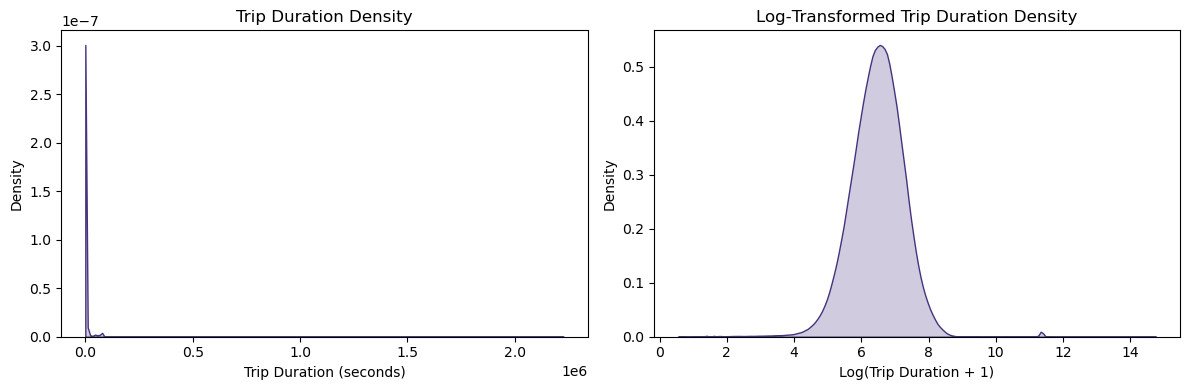

Trip Duration Statistics:


,trip_duration
count,1.000000e+06
mean,9.548850e+02
std,3.882070e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.620000e+02
75%,1.074000e+03
max,2.227612e+06


In [10]:
# Analyze trip duration distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df_train['trip_duration'],
    fill=True,
    palette='viridis'
)
plt.title('Trip Duration Density')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(
    data=np.log1p(df_train['trip_duration']),
    fill=True,
    palette='viridis'
)
plt.title('Log‑Transformed Trip Duration Density')
plt.xlabel('Log(Trip Duration + 1)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Display statistics
print("Trip Duration Statistics:")
pd.DataFrame(df_train['trip_duration'].describe())

## 6. Feature Analysis

/tmp/ipykernel_28438/1313398613.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#35A98D'` for the same effect.

  sns.countplot(


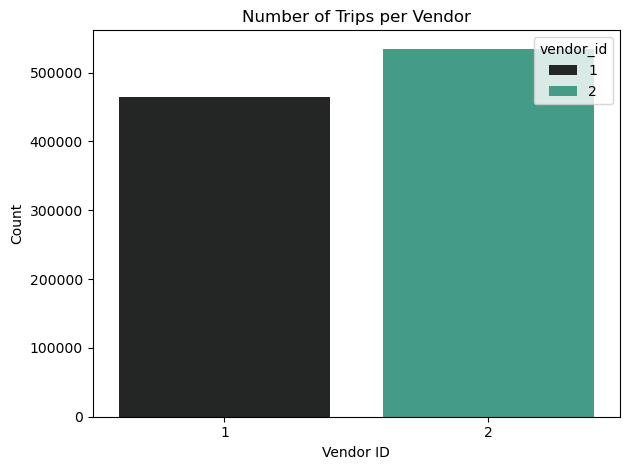

Vendor ID Value Counts:


,count
vendor_id,
2,534793
1,465207


In [11]:
# Number of trips per vendor
sns.countplot(
    data=df_train,
    x='vendor_id', 
    hue='vendor_id',
    color='#35A98D',
    legend=True
)
plt.title('Number of Trips per Vendor')
plt.xlabel('Vendor ID')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Vendor ID Value Counts:")
df_train['vendor_id'].value_counts().to_frame(name='count')

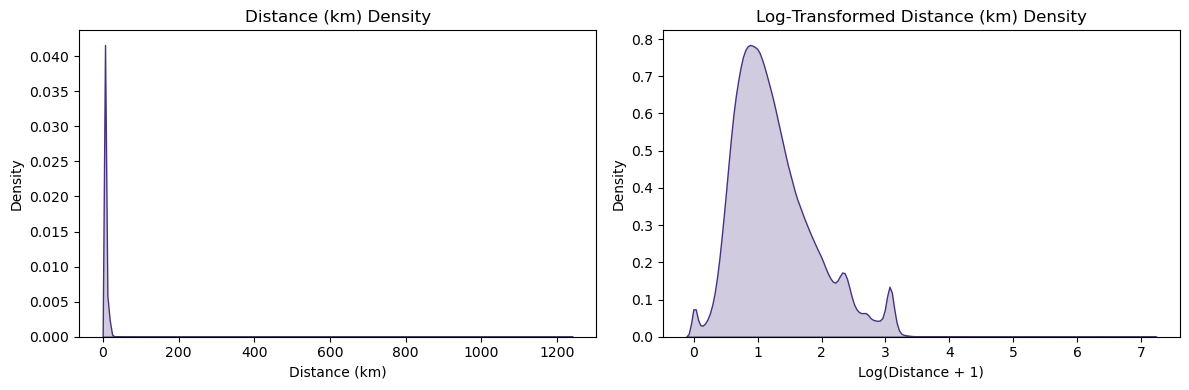

Distance Statistics:


,distance
count,1000000.000000
mean,3.439099
std,4.424258
min,0.000000
25%,1.232068
50%,2.091231
75%,3.871264
max,1240.908677


In [12]:
# Analyze distance distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df_train['distance'],
    fill=True,
)
plt.title('Distance (km) Density')
plt.xlabel('Distance (km)')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(
    data=np.log1p(df_train['distance']),
    fill=True,
)
plt.title('Log‑Transformed Distance (km) Density')
plt.xlabel('Log(Distance + 1)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()


print("Distance Statistics:")
pd.DataFrame(df_train['distance'].describe())

/tmp/ipykernel_28438/665696805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


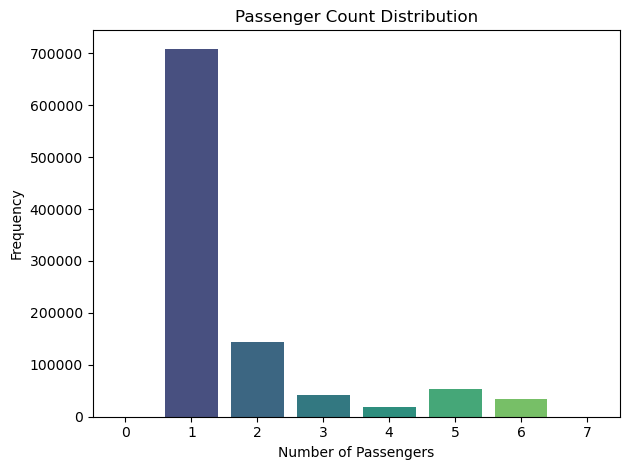

Passenger Count Statistics:


,passenger_count
count,1000000.000000
mean,1.665353
std,1.315723
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


In [13]:
# Passenger count distribution
sns.countplot(
    data=df_train,
    x='passenger_count',
    palette='viridis'
)
plt.title('Passenger Count Distribution')
plt.xlabel('Number of Passengers')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Passenger Count Statistics:")
df_train['passenger_count'].describe().to_frame()

/tmp/ipykernel_28438/1075248611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


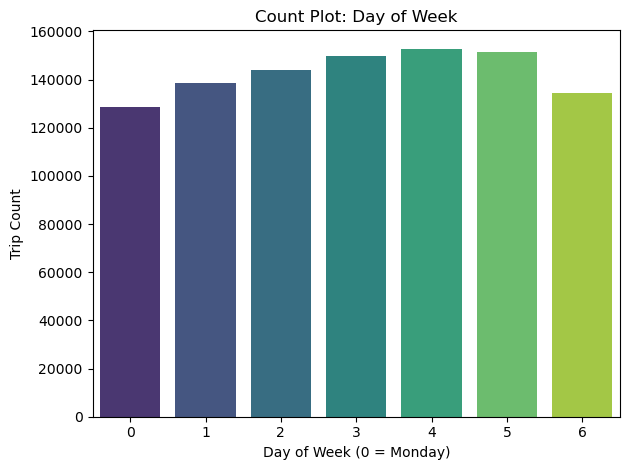

Day of Week Statistics:


,pickup_dayofweek
count,1000000.000000
mean,3.051486
std,1.954644
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,6.000000


In [14]:
# Day of week trip distribution
sns.countplot(
    data=df_train,
    x='pickup_dayofweek',
    palette='viridis'
)
plt.title('Count Plot: Day of Week')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()

print("Day of Week Statistics:")
df_train['pickup_dayofweek'].describe().to_frame()

/tmp/ipykernel_28438/419658383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


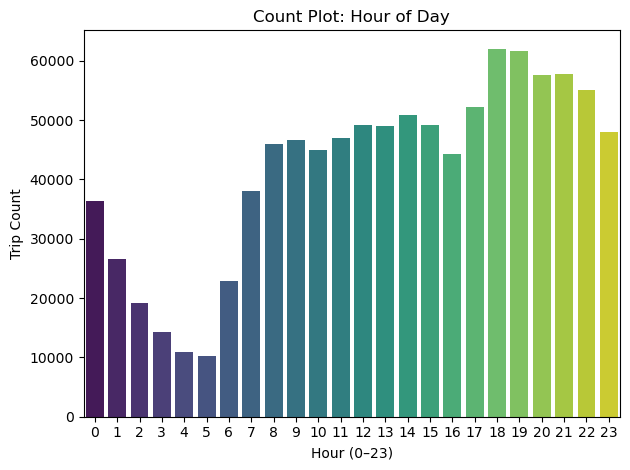

Pickup Hour Statistics:


,pickup_hour
count,1000000.000000
mean,13.604165
std,6.400685
min,0.000000
25%,9.000000
50%,14.000000
75%,19.000000
max,23.000000


In [15]:
# Hourly trip distribution
sns.countplot(
    data=df_train,
    x='pickup_hour',
    palette='viridis'
)
plt.title('Count Plot: Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()

print("Pickup Hour Statistics:")
df_train['pickup_hour'].describe().to_frame()

## 7. Relationship Analysis

/tmp/ipykernel_28438/3791713337.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


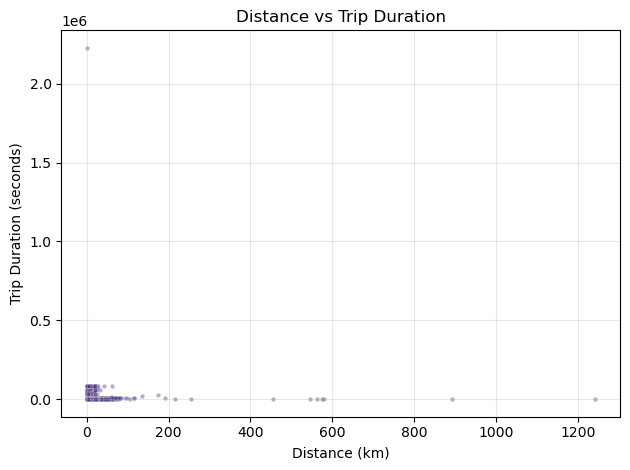

Correlation between distance and trip duration: 0.1210


In [16]:
# Distance vs Trip Duration Scatter Plot
sns.scatterplot(
    data=df_train,
    x='distance',
    y='trip_duration',
    alpha=0.4,
    s=10,
    palette='viridis'
)
plt.title('Distance vs Trip Duration')
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

correlation = df_train['distance'].corr(df_train['trip_duration'])
print(f"Correlation between distance and trip duration: {correlation:.4f}")


/tmp/ipykernel_28438/4171160008.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


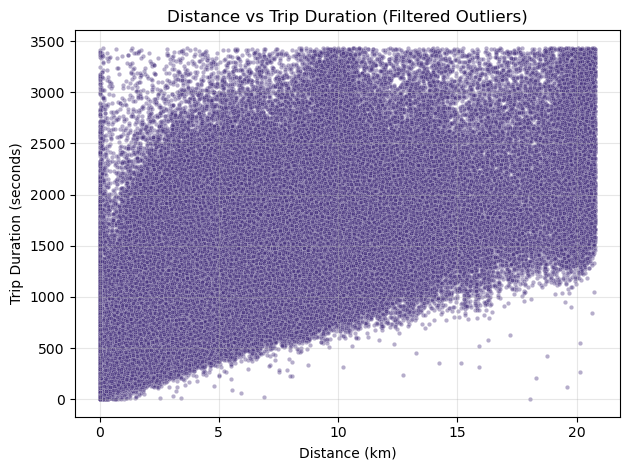

Correlation (filtered): 0.7430


In [17]:
# Distance vs Trip Duration (Filtered) Scatter Plot
filtered_df = df_train[
    (df_train['distance'] < df_train['distance'].quantile(0.99)) & 
    (df_train['trip_duration'] < df_train['trip_duration'].quantile(0.99))
]

sns.scatterplot(
    data=filtered_df,
    x='distance',
    y='trip_duration',
    alpha=0.4,
    s=10,
    palette='viridis'
)
plt.title('Distance vs Trip Duration (Filtered Outliers)')
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

filtered_correlation = filtered_df['distance'].corr(filtered_df['trip_duration'])
print(f"Correlation (filtered): {filtered_correlation:.4f}")


Outlier Removal Summary

Initial scatter plotting of `distance` vs `trip_duration` showed a noisy pattern due to extreme outliers.  
After filtering the top 1% of both columns, the relationship became much clearer and the correlation improved.  
This confirmed the decision to remove outliers for better data interpretation.


/tmp/ipykernel_28438/29166695.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/amar/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


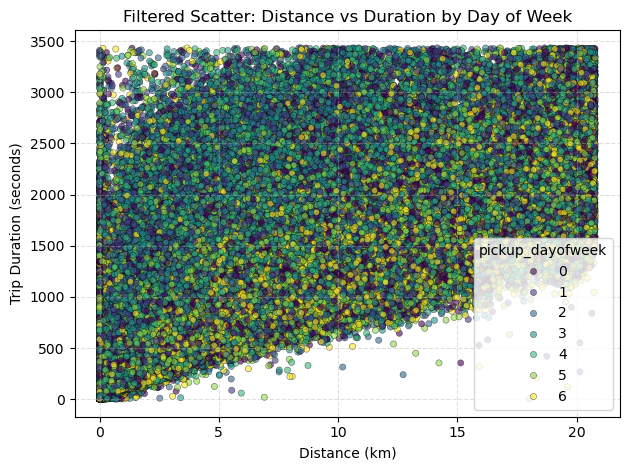

Trip Duration vs Distance (filtered) grouped by day:


distance                                               \
                     count      mean       std  min       25%       50%   
pickup_dayofweek                                                          
0                 126035.0  3.241324  3.465038  0.0  1.202564  2.026050   
1                 136478.0  3.087169  3.225926  0.0  1.191698  1.983759   
2                 141574.0  3.059165  3.153596  0.0  1.195931  1.996060   
3                 147077.0  3.121635  3.235014  0.0  1.205727  2.019081   
4                 149962.0  3.114634  3.216848  0.0  1.204273  2.032346   
5                 149592.0  3.124190  3.140859  0.0  1.261466  2.121219   
6                 132088.0  3.455748  3.541541  0.0  1.303507  2.240294   

                                      trip_duration                          \
                       75%        max         count        mean         std   
pickup_dayofweek                                                              
0                 3.751961  20.782937      126035.0  762.567152  545.375834   
1                 3.598123  20.783067      136478.0  815.172958  568.892080   
2                 3.595871  20.781948      141574.0  831.854733  578.978908   
3                 3.647281  20.783748      147077.0  845.333988  590.347512   
4                 3.668805  20.784821      149962.0  818.766628  570.410720   
5                 3.742540  20.781903      149592.0  752.815124  511.606896   
6                 4.149000  20.783526      132088.0  727.990393  516.651422   

                                                      
                  min    25%    50%      75%     max  
pickup_dayofweek                                      
0                 1.0  375.0  618.0   995.00  3434.0  
1                 1.0  403.0  668.0  1072.75  3434.0  
2                 1.0  411.0  683.0  1099.00  3432.0  
3                 1.0  414.0  695.0  1119.00  3434.0  
4                 1.0  406.0  675.0  1079.00  3433.0  
5                 1.0  382.0  627.0   990.00  3434.0  
6                 1.0  361.0  594.0   952.00  3434.0

In [18]:
# Filtered scatter with day of week hue
sns.scatterplot(
    data=filtered_df,
    x='distance',
    y='trip_duration',
    hue='pickup_dayofweek',
    edgecolor="#000",
    alpha=0.6,
    s=20,
    palette='viridis'
)
plt.title('Filtered Scatter: Distance vs Duration by Day of Week')
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Trip Duration vs Distance (filtered) grouped by day:")
filtered_df.groupby('pickup_dayofweek')[['distance', 'trip_duration']].describe()

/tmp/ipykernel_28438/1533502584.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/amar/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


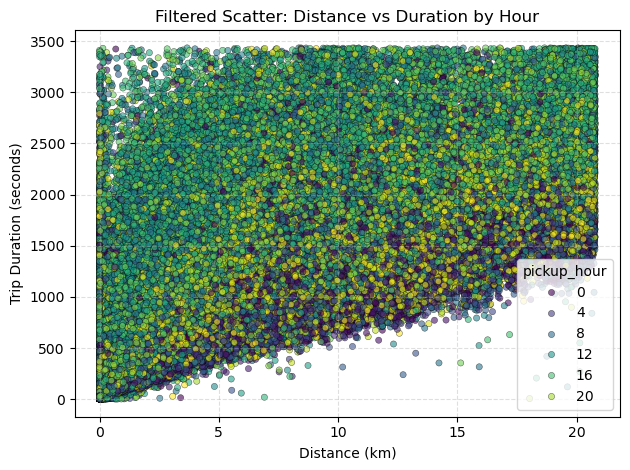

Trip Duration vs Distance (filtered) grouped by hour:


distance                                                         \
               count      mean       std  min       25%       50%       75%   
pickup_hour                                                                   
0            35942.0  3.800041  3.509158  0.0  1.452047  2.624916  4.964030   
1            26360.0  3.798245  3.439995  0.0  1.443372  2.645726  5.064414   
2            18981.0  3.772945  3.360449  0.0  1.406954  2.644642  5.171756   
3            14241.0  4.020167  3.581267  0.0  1.457147  2.825460  5.583435   
4            10658.0  4.581650  4.185933  0.0  1.519117  3.147985  6.524458   
5             9904.0  4.870235  4.959920  0.0  1.436616  2.848216  6.751923   
6            22224.0  3.648606  3.905067  0.0  1.276915  2.239952  4.303609   
7            37295.0  3.044288  3.059341  0.0  1.221574  2.043951  3.594959   
8            45297.0  2.771041  2.815711  0.0  1.138420  1.850871  3.217378   
9            46060.0  2.752322  2.843728  0.0  1.124069  1.831811  3.177004   
10           44373.0  2.808812  2.902618  0.0  1.135541  1.846328  3.218379   
11           46315.0  2.872689  3.083180  0.0  1.148271  1.866132  3.232893   
12           48416.0  2.841357  3.109313  0.0  1.120195  1.826243  3.177207   
13           48052.0  2.948181  3.288539  0.0  1.132912  1.851031  3.268180   
14           49465.0  2.988582  3.353209  0.0  1.144813  1.871098  3.306299   
15           47755.0  2.936521  3.235828  0.0  1.141785  1.863050  3.262371   
16           42713.0  2.952394  3.238905  0.0  1.155848  1.880637  3.274705   
17           50877.0  2.889316  3.049774  0.0  1.182617  1.927362  3.274634   
18           61034.0  2.835761  2.955799  0.0  1.186214  1.921254  3.268773   
19           61011.0  2.932363  3.051696  0.0  1.200524  1.974027  3.393900   
20           56918.0  3.236936  3.310417  0.0  1.287737  2.165603  3.812016   
21           57118.0  3.411356  3.365795  0.0  1.353122  2.318718  4.121884   
22           54367.0  3.565548  3.421891  0.0  1.409813  2.427942  4.422553   
23           47430.0  3.803610  3.582961  0.0  1.443147  2.586981  4.849868   

                       trip_duration                                       \
                   max         count        mean         std  min     25%   
pickup_hour                                                                 
0            20.781948       35942.0  763.946135  512.930846  1.0  387.00   
1            20.769456       26360.0  719.302428  471.654617  2.0  371.00   
2            20.645097       18981.0  692.814025  457.583864  1.0  354.00   
3            20.766653       14241.0  694.157573  458.670127  2.0  348.00   
4            20.776414       10658.0  711.088572  482.047146  1.0  338.00   
5            20.776274        9904.0  669.767266  514.340662  1.0  283.00   
6            20.780535       22224.0  607.949019  488.057744  2.0  287.00   
7            20.777695       37295.0  695.350422  499.998363  2.0  351.00   
8            20.779432       45297.0  791.758924  557.677201  2.0  390.00   
9            20.781773       46060.0  815.019952  566.147764  1.0  402.00   
10           20.775902       44373.0  817.924571  568.831535  2.0  400.00   
11           20.779764       46315.0  842.793415  580.066007  1.0  419.00   
12           20.780674       48416.0  842.076648  578.021529  1.0  417.00   
13           20.783748       48052.0  848.801403  588.542193  1.0  418.75   
14           20.783526       49465.0  873.212534  622.367978  1.0  422.00   
15           20.777819       47755.0  875.145158  638.659596  2.0  418.00   
16           20.784736       42713.0  855.657505  646.622534  1.0  397.00   
17           20.783579       50877.0  850.843230  622.038649  1.0  406.00   
18           20.783067       61034.0  819.596569  571.542645  2.0  409.00   
19           20.779772       61011.0  767.466227  517.133109  1.0  393.00   
20           20.783075       56918.0  746.301978  494.147971  2.0  388.00   
21           20.782937       5

In [19]:
# Filtered scatter with hour of day hue
sns.scatterplot(
    data=filtered_df,
    x='distance',
    y='trip_duration',
    hue='pickup_hour',
    palette='viridis',
    edgecolor="#000",
    alpha=0.6,
    s=20
)
plt.title('Filtered Scatter: Distance vs Duration by Hour')
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Trip Duration vs Distance (filtered) grouped by hour:")
filtered_df.groupby('pickup_hour')[['distance', 'trip_duration']].describe()

/tmp/ipykernel_28438/1229915153.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


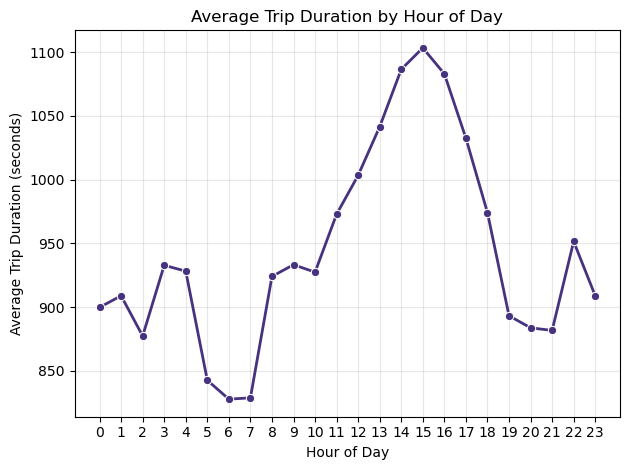

Average Trip Duration by Hour:


,avg_trip_duration
pickup_hour,
0,899.763964
1,908.880072
2,877.313576
3,932.781616
4,928.147609
5,842.601544
6,827.789949
7,828.817451
8,924.013608


In [20]:
# Average trip duration by hour of day
hourly_duration = df_train.groupby('pickup_hour')['trip_duration'].mean().reset_index()

sns.lineplot(
    data=hourly_duration,
    x='pickup_hour',
    y='trip_duration',
    marker='o',
    linewidth=2,
    palette='viridis'
    )
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (seconds)')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print("Average Trip Duration by Hour:")
hourly_duration.rename(columns={'trip_duration': 'avg_trip_duration'}).set_index('pickup_hour')

## 8. Correlation Analysis

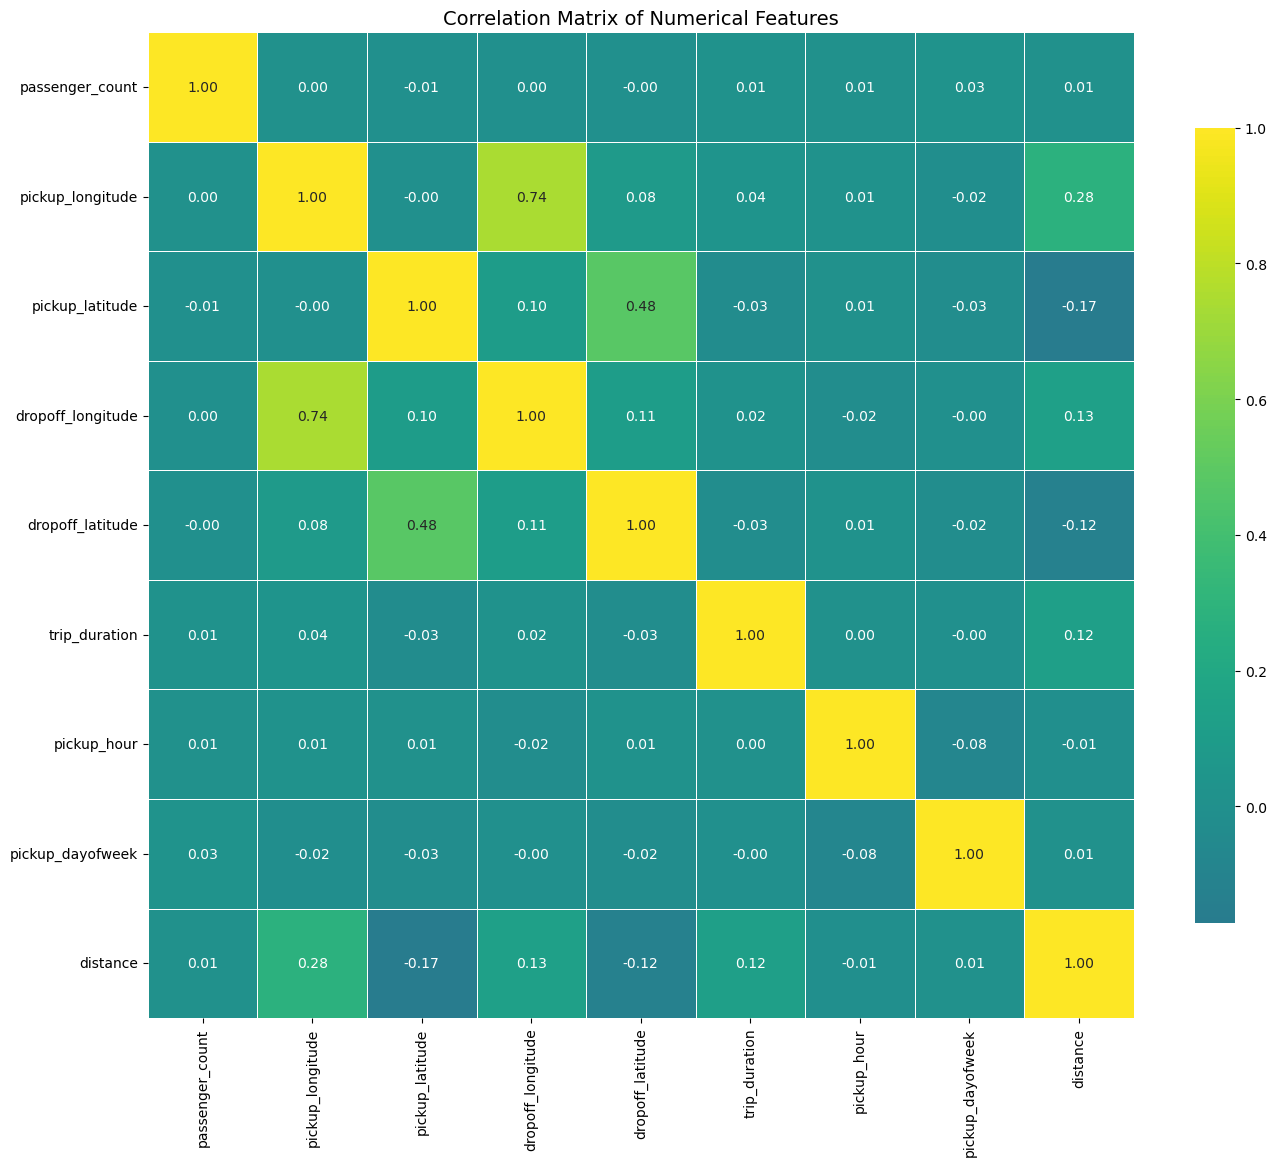

Correlation Matrix:


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,distance
passenger_count,1.000000,0.002454,-0.005634,0.000026,-0.002635,0.012249,0.009674,0.025116,0.010310
pickup_longitude,0.002454,1.000000,-0.000421,0.740031,0.084609,0.035457,0.012217,-0.018040,0.279612
pickup_latitude,-0.005634,-0.000421,1.000000,0.102461,0.480229,-0.034007,0.010992,-0.028199,-0.171702
dropoff_longitude,0.000026,0.740031,0.102461,1.000000,0.108450,0.021856,-0.023283,-0.001882,0.127283
dropoff_latitude,-0.002635,0.084609,0.480229,0.108450,1.000000,-0.027749,0.013798,-0.021652,-0.124886
trip_duration,0.012249,0.035457,-0.034007,0.021856,-0.027749,1.000000,0.003349,-0.001787,0.120961
pickup_hour,0.009674,0.012217,0.010992,-0.023283,0.013798,0.003349,1.000000,-0.084474,-0.014580
pickup_dayofweek,0.025116,-0.018040,-0.028199,-0.001882,-0.021652,-0.001787,-0.084474,1.000000,0.007177
distance,0.010310,0.279612,-0.171702,0.127283,-0.124886,0.120961,-0.014580,0.007177,1.000000


In [21]:
# Correlation matrix heatmap (improved)
numerical_cols = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 
    'pickup_hour', 'pickup_dayofweek', 'distance'
]

correlation_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cmap='viridis',
    center=0,
    square=True,
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'shrink': 0.75}
)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
correlation_matrix


## 9. Log-Transforming Skewed Features

In [22]:
# Log-Transforming Skewed Features for Normalization

df_train['distance'] = np.log1p(df_train['distance'])
df_train['trip_duration'] = np.log1p(df_train['trip_duration'])


## 10. Outlier Analysis

/tmp/ipykernel_28438/690833922.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


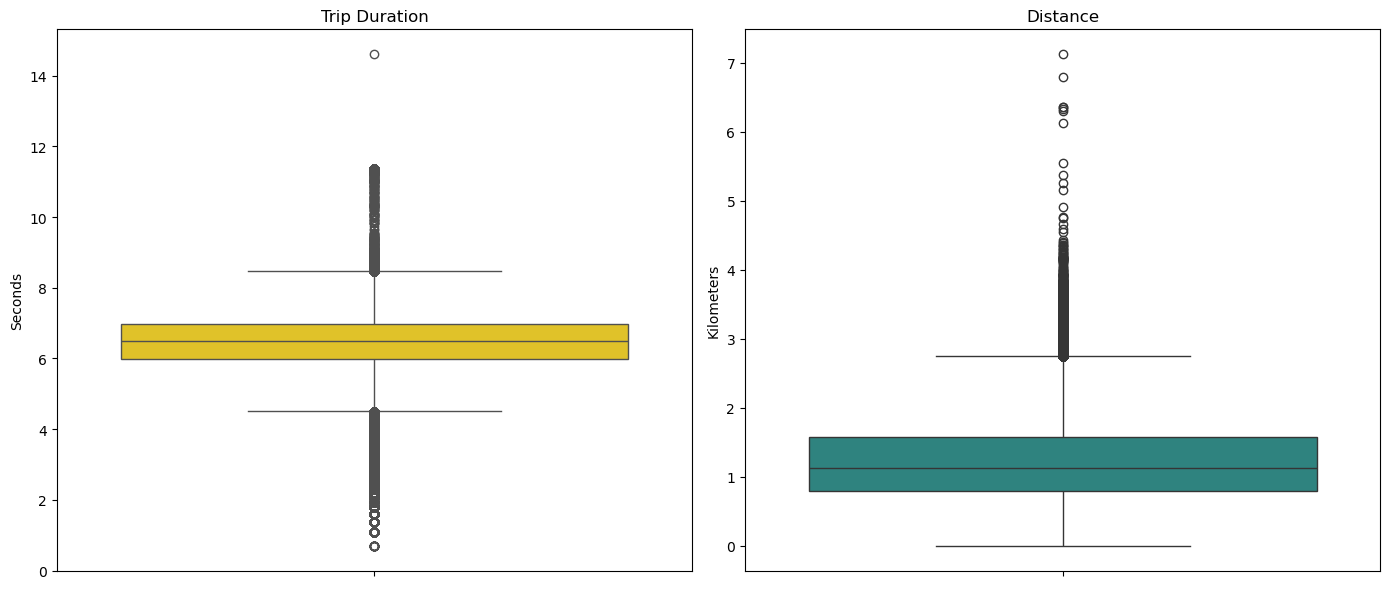

Trip Duration & Distance Statistics:


,trip_duration,distance
count,1000000.000000,1000000.000000
mean,6.466492,1.253956
std,0.794744,0.626970
min,0.693147,0.000000
25%,5.986452,0.802929
50%,6.496775,1.128569
75%,6.980076,1.583353
max,14.616441,7.124405


In [23]:
# Box plots for key numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_train,
    y='trip_duration',
    ax=axes[0],
    color='#FFD60A'
)
axes[0].set_title('Trip Duration')
axes[0].set_ylabel('Seconds')

sns.boxplot(
    data=df_train,
    y='distance',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Distance')
axes[1].set_ylabel('Kilometers')

plt.tight_layout()
plt.show()

print("Trip Duration & Distance Statistics:")
df_train[['trip_duration', 'distance']].describe()

## 11. Handling Outlier

In [24]:
def remove_outliers(df, cols, threshold=1.5):
    """
    Drop rows whose values in the given column(s) lie outside the IQR fence.

    df         : pandas DataFrame
    cols       : str or list of str
    threshold  : multiplier for IQR (default 1.5)
    """
    if isinstance(cols, str):
        cols = [cols]

    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df = df[df[col].between(q1 - threshold * iqr, q3 + threshold * iqr)]

    return df

df_train = remove_outliers(df_train, ['distance', 'trip_duration'], threshold=1.2)

/tmp/ipykernel_28438/690833922.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


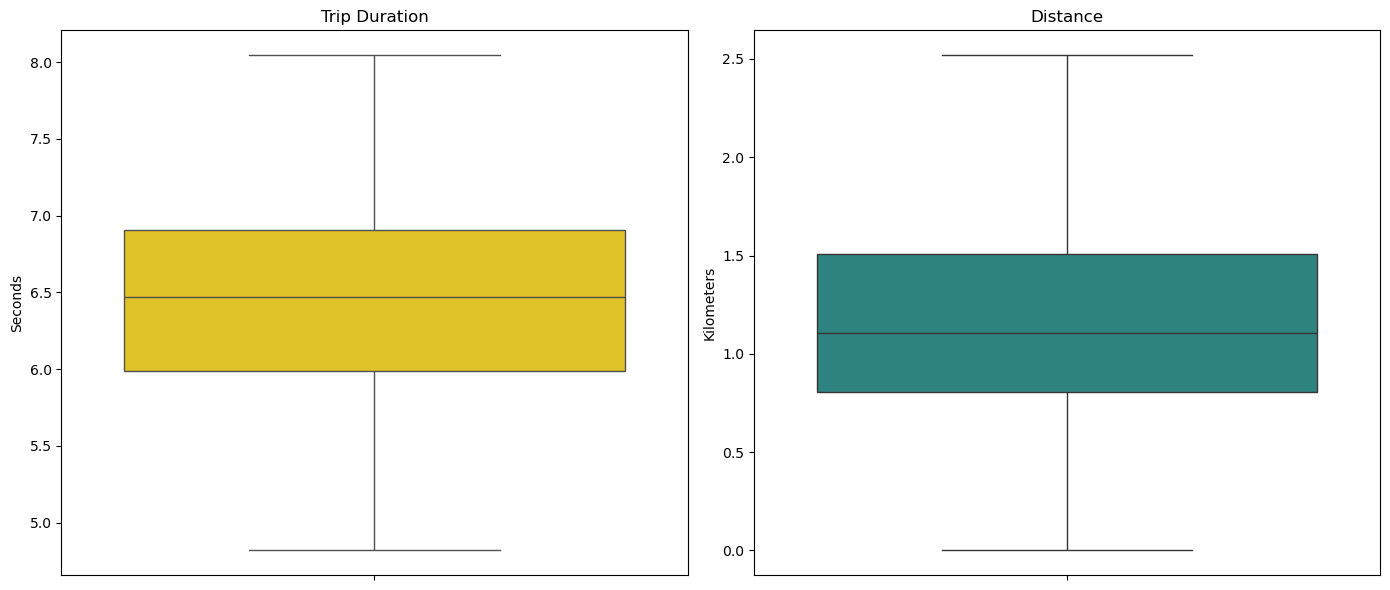

Trip Duration & Distance Statistics:


,trip_duration,distance
count,928645.000000,928645.000000
mean,6.440247,1.187940
std,0.642708,0.506587
min,4.820282,0.000000
25%,5.991465,0.806094
50%,6.467699,1.107719
75%,6.909753,1.505935
max,8.045588,2.519853


In [25]:
# Box plots for key numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_train,
    y='trip_duration',
    ax=axes[0],
    color='#FFD60A'
)
axes[0].set_title('Trip Duration')
axes[0].set_ylabel('Seconds')

sns.boxplot(
    data=df_train,
    y='distance',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Distance')
axes[1].set_ylabel('Kilometers')

plt.tight_layout()
plt.show()

print("Trip Duration & Distance Statistics:")
df_train[['trip_duration', 'distance']].describe()

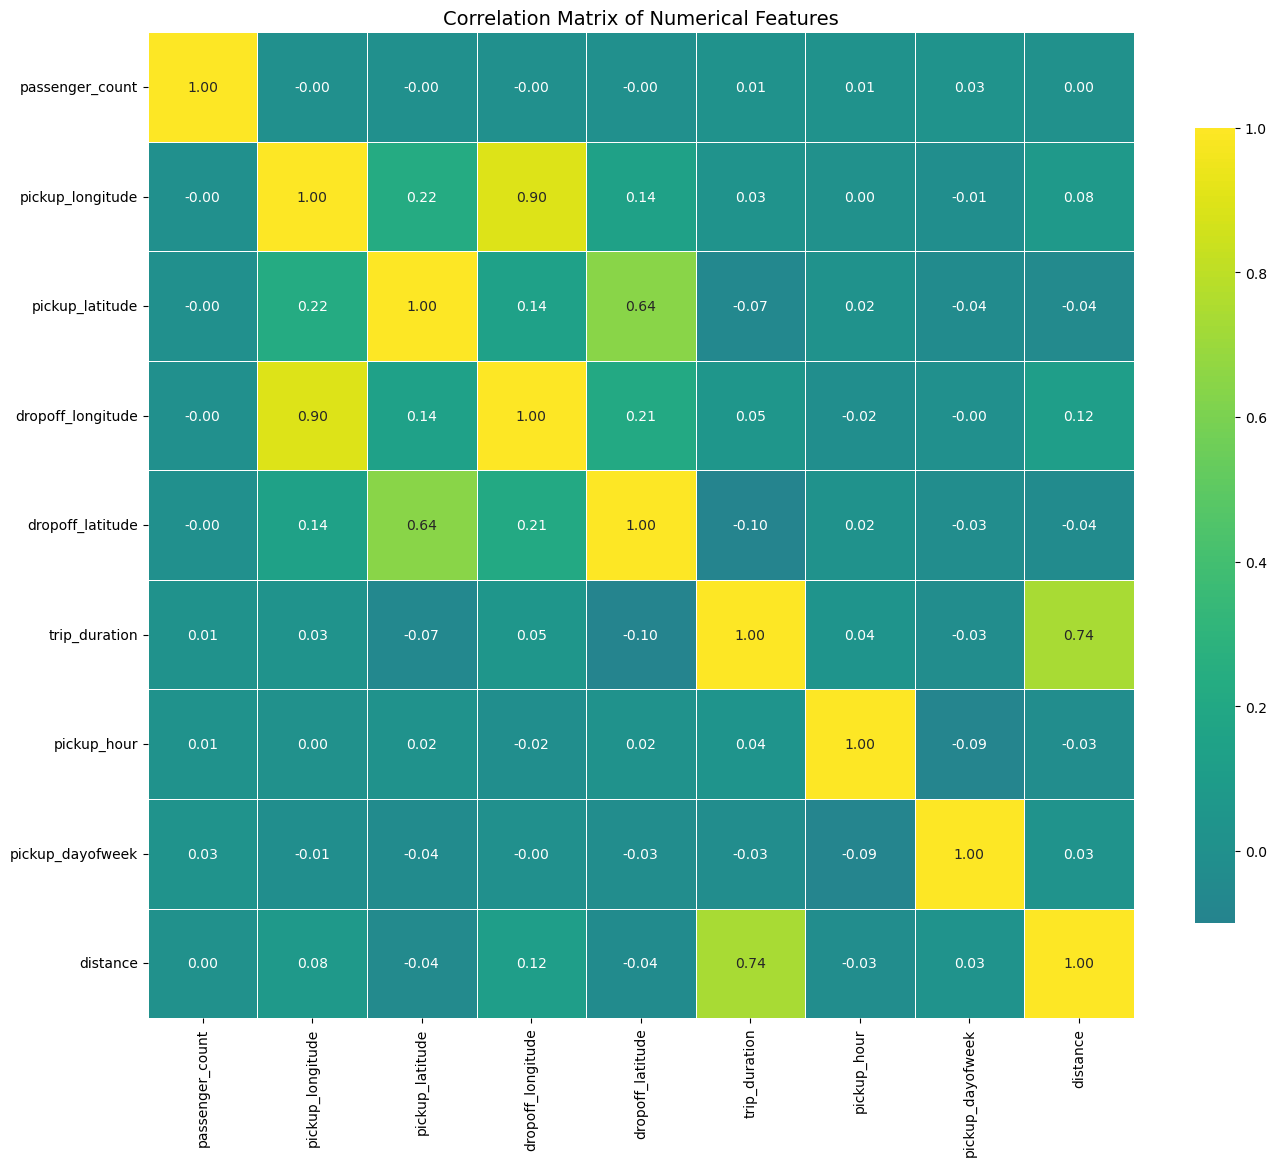

Correlation Matrix:


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,distance
passenger_count,1.000000,-0.001001,-0.002936,-0.001130,-0.001216,0.011050,0.009722,0.025882,0.004270
pickup_longitude,-0.001001,1.000000,0.223142,0.896608,0.142923,0.031341,0.001105,-0.014348,0.077017
pickup_latitude,-0.002936,0.223142,1.000000,0.139184,0.644472,-0.067244,0.022461,-0.042161,-0.043512
dropoff_longitude,-0.001130,0.896608,0.139184,1.000000,0.209580,0.048593,-0.020773,-0.003362,0.116722
dropoff_latitude,-0.001216,0.142923,0.644472,0.209580,1.000000,-0.099117,0.016696,-0.029765,-0.040646
trip_duration,0.011050,0.031341,-0.067244,0.048593,-0.099117,1.000000,0.037892,-0.030000,0.737555
pickup_hour,0.009722,0.001105,0.022461,-0.020773,0.016696,0.037892,1.000000,-0.086183,-0.026435
pickup_dayofweek,0.025882,-0.014348,-0.042161,-0.003362,-0.029765,-0.030000,-0.086183,1.000000,0.029755
distance,0.004270,0.077017,-0.043512,0.116722,-0.040646,0.737555,-0.026435,0.029755,1.000000


In [26]:
# Correlation matrix heatmap (improved)
numerical_cols = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude', 'trip_duration', 
    'pickup_hour', 'pickup_dayofweek', 'distance'
]

correlation_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cmap='viridis',
    center=0,
    square=True,
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'shrink': 0.75}
)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
correlation_matrix


## 12. Feature Selection

In [27]:
# Dropping Redundant or Non-Predictive Columns

df_train.drop(
    columns=[
        'id',
        'vendor_id',
        'pickup_datetime',
    ],
    inplace=True
)


The following columns were removed from the dataset for the reasons below:

- **`id`**: This column contains unique identifiers for each trip and holds no predictive value.

- **`vendor_id`**: This represents the taxi company. From a logical perspective, it’s unlikely to significantly affect trip duration.

- **`pickup_datetime`**: This column was decomposed into more informative features: `pickup_hour` and `pickup_dayofweek`, which capture temporal patterns more directly.


In [28]:
# Removing Trips with Zero Distance

df_train = df_train[df_train['distance'] != 0]



Excluded trips with a `distance` of 0, as they are likely errors or invalid records.


In [29]:
# Checking for Duplicate Rows

df_train.duplicated().sum()


2

In [30]:
# Removing Duplicate Rows

df_train.drop_duplicates(inplace=True)


In [31]:
# Feature Importance using Mutual Information Regression

features = df_train.drop(columns=['trip_duration'])
target = df_train['trip_duration']

X = features.select_dtypes(include='number')
y = target

importances = mutual_info_regression(X, y, random_state=0)
mi_scores = pd.Series(importances, index=X.columns).sort_values(ascending=False)

pd.DataFrame(mi_scores)


,0
distance,0.443425
dropoff_latitude,0.035287
dropoff_longitude,0.030901
pickup_longitude,0.029466
pickup_latitude,0.021667
pickup_hour,0.009018
pickup_dayofweek,0.005044
pickup_month,0.002361
pickup_minute,0.000504
passenger_count,0.000000


/tmp/ipykernel_28438/171396465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


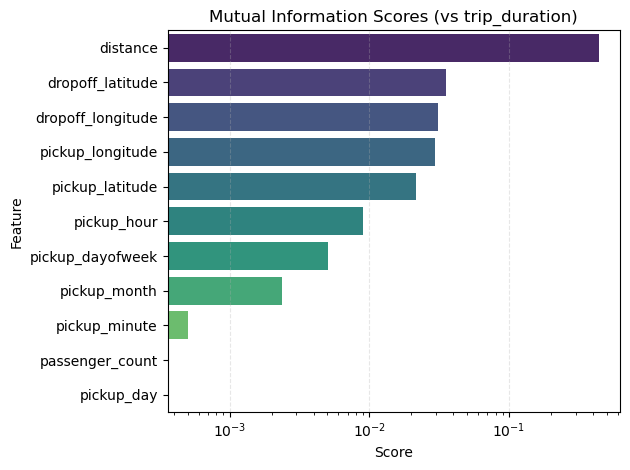

In [32]:
# Visualizing Mutual Information Scores for Numerical Features

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index,
    palette='viridis'
)
plt.title("Mutual Information Scores (vs trip_duration)")
plt.xlabel("Score")
plt.ylabel("Feature")
plt.xscale('log')
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Dropping 'passenger_count','pickup_day','store_and_fwd_flag' After Feature Evaluation

df_train.drop(['passenger_count','pickup_day','store_and_fwd_flag','pickup_minute'], axis=1, inplace=True)

## 13. Save Cleaned Dataset

In [34]:
df_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,distance
0,-73.985611,40.735943,-73.980331,40.760468,6.947937,7,2,6,1.325230
1,-73.978394,40.764351,-73.991623,40.749859,6.719013,12,6,4,1.084912
2,-73.989059,40.744389,-73.973381,40.748692,6.421622,2,6,6,0.877455
3,-73.990326,40.731136,-73.991264,40.748917,6.766192,17,3,5,1.091473
5,-73.969833,40.768570,-73.962646,40.767181,5.926926,12,3,4,0.485277
...,...,...,...,...,...,...,...,...,...
999995,-73.959106,40.771770,-73.953995,40.786312,5.541264,15,4,3,0.983298
999996,-73.970978,40.764015,-73.956230,40.777851,6.075346,19,2,5,1.090979
999997,-73.982178,40.771240,-73.970749,40.758968,7.175490,8,3,5,0.982033
999998,-73.982513,40.765533,-74.005974,40.711842,7.748460,14,0,4,1.986360


In [35]:
df_train.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,distance
count,925906.000000,925906.000000,925906.000000,925906.000000,925906.000000,925906.000000,925906.000000,925906.000000,925906.000000
mean,-73.978031,40.752999,-73.975942,40.753102,6.440580,13.629057,3.050141,3.510854,1.191454
std,0.056106,0.024091,0.056415,0.028088,0.642587,6.380260,1.950763,1.680119,0.503194
min,-121.933342,37.389381,-121.933304,37.389511,4.820282,0.000000,0.000000,1.000000,0.000424
25%,-73.992096,40.738636,-73.991425,40.737560,5.991465,9.000000,1.000000,2.000000,0.808733
50%,-73.982101,40.754704,-73.980209,40.755009,6.467699,14.000000,3.000000,4.000000,1.109563
75%,-73.968971,40.768429,-73.964783,40.769794,6.909753,19.000000,5.000000,5.000000,1.507546
max,-73.384659,41.696796,-73.384666,41.693352,8.045588,23.000000,6.000000,6.000000,2.519853
